In [15]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42



# CE cardinality sensitivity by workload


In [16]:
from pathlib import Path
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt


In [17]:
def _find_repo_root(start: Path) -> Path:
    markers = [
        Path("tasks/cardinality_estimation/ce_timeline_census"),
        Path("existing_benchmarks/AreCELearnedYet"),
    ]
    for candidate in [start] + list(start.parents):
        if all((candidate / m).exists() for m in markers):
            return candidate
    return start


REPO_ROOT_OVERRIDE = None  # e.g. "/Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator"
REPO_ROOT = (
    Path(REPO_ROOT_OVERRIDE).expanduser() if REPO_ROOT_OVERRIDE else _find_repo_root(Path.cwd())
)
print(f"CWD: {Path.cwd()}")
print(f"Using REPO_ROOT: {REPO_ROOT}")

RESULT_DIRS = [
    REPO_ROOT / "tasks/cardinality_estimation/ce_timeline_census/result/census13",
    REPO_ROOT / "existing_benchmarks/AreCELearnedYet/output/result/census13",
    REPO_ROOT / "existing_benchmarks/AreCELearnedYet/tasks/cardinality_estimation/ce_timeline_census/result/census13",
]
BASELINE_RESULT_DIR = RESULT_DIRS[0]
LOG_DIR = REPO_ROOT / "tasks/cardinality_estimation/ce_timeline_census/log/ce_timeline"
DATASET_TAG = "census"
BASE_VERSION = "original"
ESTIMATORS = ["naru", "mscn", "postgres"]
WORKLOAD_ALLOWLIST = None  # e.g. {"original_normal_sqls", "original_sqls_selectivity_3"}
INCLUDE_BASELINE = False  # include base version as step 0
PRINT_BASELINE_PATHS = True
FALLBACK_VALUE = 0.0  # used when data is missing or empty
USE_LOG_SCALE = False
SAVE_FIGS = True
OUTPUT_DIR = REPO_ROOT / "tasks/cardinality_estimation/ce_timeline_census/figures"
OVERLEAF_DIR = "/Users/guanlil1/Dropbox/应用/Overleaf/DataWorkloadGen/figures"

def _save_fig(fig, file_name):
    if not SAVE_FIGS or not file_name:
        return
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / f"{file_name}.png", format="png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{file_name}.pdf", format="pdf", bbox_inches="tight")
    if OVERLEAF_DIR:
        overleaf = Path(OVERLEAF_DIR).expanduser()
        overleaf.mkdir(parents=True, exist_ok=True)
        fig.savefig(overleaf / f"{file_name}.pdf", format="pdf", bbox_inches="tight")
PLOT_STYLE = "boxplot"  # "scatter" or "boxplot"
SEGMENTS_PER_STEP = 10  # show one time point per step
BOX_WIDTH = 1.0
MIN_ERROR = 1e-6
JITTER = 0.15
SCATTER_ALPHA = 0.15
SCATTER_SIZE = 6
FIGSIZE = (12, 4)
FONT_SIZE = 24
TITLE_SIZE = 24
TICK_SIZE = 24
plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "figure.titlesize": TITLE_SIZE,
})



CWD: /Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator/tasks/cardinality_estimation/ce_timeline_census/notebooks
Using REPO_ROOT: /Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator


In [18]:
def _parse_result_name(path: Path, dataset_tag: str):
    if path.suffix != ".csv":
        return None
    base = path.stem
    if "-version=" in base:
        base = base.split("-version=", 1)[0]
    marker = f"-{dataset_tag}_"
    if marker not in base:
        return None
    if "-" not in base:
        return None
    base, estimator = base.rsplit("-", 1)
    if estimator not in ESTIMATORS:
        return None
    version, workload = base.split(marker, 1)
    return version, workload, estimator


def _parse_log_name(path: Path, dataset_tag: str):
    if path.suffix != ".log":
        return None
    base = path.stem
    marker = f"_{dataset_tag}_"
    if marker not in base:
        return None
    version, rest = base.split(marker, 1)
    if "_" not in rest:
        return None
    workload, estimator = rest.rsplit("_", 1)
    if estimator not in ESTIMATORS:
        return None
    return version, workload, estimator


def _cardinality_step(version: str):
    if version == BASE_VERSION:
        return 0 if INCLUDE_BASELINE else None
    match = re.search(r"cardinality[_-]?t?(\d+)", version)
    if match:
        return int(match.group(1))
    return None



START_TIME = dt.datetime(2026, 1, 10, 0, 0)
STEP_MINUTES = 10

def _time_label(step: int, show_date: bool) -> str:
    if step is None:
        return ""
    idx = int(max(step - 1, 0))
    ts = START_TIME + dt.timedelta(minutes=STEP_MINUTES * idx)
    return ts.strftime("%m-%d %H:%M") if show_date else ts.strftime("%H:%M")


def _step_labels(steps):
    labels = []
    for i, step in enumerate(steps):
        labels.append(_time_label(step, show_date=(i == 0)))
    return labels


def _read_errors(path: Path):
    try:
        df = pd.read_csv(path)
    except Exception:
        return [FALLBACK_VALUE]
    if "error" not in df.columns:
        return [FALLBACK_VALUE]
    values = df["error"].dropna().tolist()
    return values if values else [FALLBACK_VALUE]


def _collect_results():
    entries = []
    for result_dir in RESULT_DIRS:
        if not result_dir.exists():
            continue
        for path in result_dir.glob("*.csv"):
            parsed = _parse_result_name(path, DATASET_TAG)
            if not parsed:
                continue
            version, workload, estimator = parsed
            step = _cardinality_step(version)
            if step is None:
                continue
            if version == BASE_VERSION:
                expected = f"{BASE_VERSION}-{DATASET_TAG}_{workload}-{estimator}.csv"
                if path.parent != BASELINE_RESULT_DIR or path.name != expected:
                    continue
            entries.append({
                "version": version,
                "workload": workload,
                "estimator": estimator,
                "step": step,
                "path": path,
            })
    return entries


def _collect_expected_from_logs():
    expected = {}
    if not LOG_DIR.exists():
        return expected
    for path in LOG_DIR.glob("*.log"):
        parsed = _parse_log_name(path, DATASET_TAG)
        if not parsed:
            continue
        version, workload, estimator = parsed
        step = _cardinality_step(version)
        if step is None:
            continue
        expected[(version, workload, estimator)] = step
    return expected


In [19]:
entries = _collect_results()
expected = _collect_expected_from_logs()

if not entries and not expected:
    print("No matches found. Checked paths:")
    for p in RESULT_DIRS:
        print(f"  RESULT_DIR: {p} (exists={p.exists()})")
    print(f"  LOG_DIR: {LOG_DIR} (exists={LOG_DIR.exists()})")
    print("Tip: set REPO_ROOT_OVERRIDE to your repo path and rerun this cell.")
    raise RuntimeError("No results or logs found. Check RESULT_DIRS, LOG_DIR, and DATASET_TAG.")

# Pick the first match per (version, workload, estimator) based on RESULT_DIRS order.
priority = {str(d): i for i, d in enumerate(RESULT_DIRS)}
entries.sort(key=lambda e: priority.get(str(e["path"].parent), 99))

selected = {}
for e in entries:
    key = (e["version"], e["workload"], e["estimator"])
    if key not in selected:
        selected[key] = e

if PRINT_BASELINE_PATHS:
    baseline = [e for e in selected.values() if e["version"] == BASE_VERSION]
    if baseline:
        print("Baseline files (step 0):")
        for e in sorted(baseline, key=lambda r: (r["workload"], r["estimator"])):
            print(f"  {e['workload']} {e['estimator']}: {e['path']}")
records = []
for e in selected.values():
    errors = _read_errors(e["path"])
    records.append({
        "version": e["version"],
        "workload": e["workload"],
        "estimator": e["estimator"],
        "step": e["step"],
        "errors": errors,
    })

# Add missing entries based on logs, filled with fallback values.
for (version, workload, estimator), step in expected.items():
    key = (version, workload, estimator)
    if key in selected:
        continue
    records.append({
        "version": version,
        "workload": workload,
        "estimator": estimator,
        "step": step,
        "errors": [FALLBACK_VALUE],
    })

df = pd.DataFrame(records)
if WORKLOAD_ALLOWLIST:
    df = df[df["workload"].isin(WORKLOAD_ALLOWLIST)]

workloads = sorted(df["workload"].unique())
workloads
workloads = ['original_sqls_selectivity_1']

In [20]:
def _build_workload_data(df, workload):
    sub = df[df["workload"] == workload]
    steps = sorted(sub["step"].unique())
    data = {step: {est: [FALLBACK_VALUE] for est in ESTIMATORS} for step in steps}
    for _, row in sub.iterrows():
        data[row["step"]][row["estimator"]] = row["errors"] or [FALLBACK_VALUE]
    return steps, data


def _prep_values(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    if USE_LOG_SCALE:
        arr = np.clip(arr, MIN_ERROR, None)
    return arr


def _segment_values(values, segments):
    arr = _prep_values(values)
    if segments <= 1:
        return [arr]
    if arr.size == 0:
        return [np.asarray([FALLBACK_VALUE], dtype=float) for _ in range(segments)]
    splits = np.array_split(arr, segments)
    out = []
    for s in splits:
        if s.size == 0:
            out.append(np.asarray([FALLBACK_VALUE], dtype=float))
        else:
            out.append(s)
    return out


def plot_workload(workload):
    steps, data = _build_workload_data(df, workload)
    labels = _step_labels(steps)
    if not steps:
        return

    colors = {
        "postgres": "#4C78A8",
        "naru": "#F58518",
        "mscn": "#54A24B",
    }

    n = len(ESTIMATORS)
    fig, axes = plt.subplots(1, n, figsize=(FIGSIZE[0] * n, FIGSIZE[1]), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, est in zip(axes, ESTIMATORS):
        for i, step in enumerate(steps):
            segments = _segment_values(data[step].get(est, [FALLBACK_VALUE]), SEGMENTS_PER_STEP)
            for seg_idx, values in enumerate(segments):
                if values.size == 0:
                    continue
                jitter = np.random.uniform(-JITTER, JITTER, size=values.size)
                x_index = i * SEGMENTS_PER_STEP + seg_idx
                x = np.full(values.size, x_index) + jitter
                ax.scatter(
                    x,
                    values,
                    s=SCATTER_SIZE,
                    alpha=SCATTER_ALPHA,
                    color=colors[est],
                    edgecolors="none",
                )
                median = float(np.median(values)) if values.size else np.nan
                ax.scatter(
                    [x_index],
                    [median],
                    s=24,
                    color=colors[est],
                    edgecolors="black",
                    linewidths=0.3,
                )

        ax.set_title(f"Q-error Distribution Across {est}", fontsize=24)
        if SEGMENTS_PER_STEP <= 1:
            ax.set_xticks(range(len(labels)))
            ax.set_xticklabels(labels)
            # ax.set_xlabel("time (10 min steps)")
        else:
            total = len(steps) * SEGMENTS_PER_STEP
            centers_1 = [i * SEGMENTS_PER_STEP for i in range(len(steps))]
            # centers_1[0] = -1
            centers_2 = [i * SEGMENTS_PER_STEP + (SEGMENTS_PER_STEP - 1) / 2 for i in range(len(steps))]
            ax.set_xticks(centers_1)
            ax.set_xticklabels(labels, rotation=0, ha="left")
            # ax.set_xlabel("time (10 min steps)")
            for i in range(1, len(steps)):
                ax.axvline(i * SEGMENTS_PER_STEP - 0.5, linestyle="--", color="gray", alpha=0.4, linewidth=0.8)
            ax_top = ax.twiny()
            ax_top.set_xlim(ax.get_xlim())
            workload_labels = [f"W{i+1}" for i in range(len(steps))]
            ax_top.set_xticks(centers_2)
            ax_top.set_xticklabels(workload_labels, fontsize=TICK_SIZE)
            # ax_top.set_xlabel("workload")
    axes[0].set_ylabel("Q-error" + (" (log scale)" if USE_LOG_SCALE else ""))
    if USE_LOG_SCALE:
        axes[0].set_yscale("log")
    fig.tight_layout()
    _save_fig(fig, f"{workload}_scatter")


if PLOT_STYLE == "scatter":
    for workload in workloads:
        plot_workload(workload)


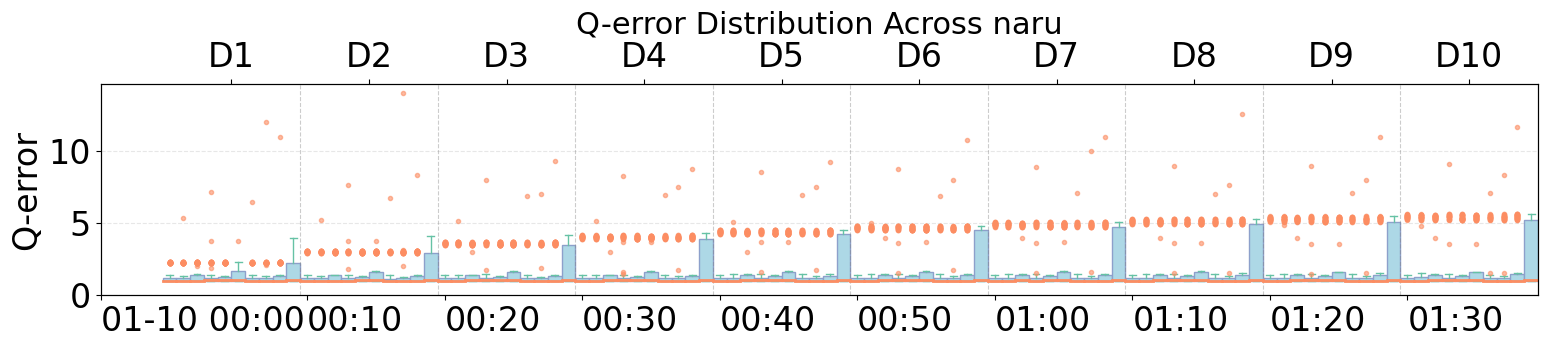

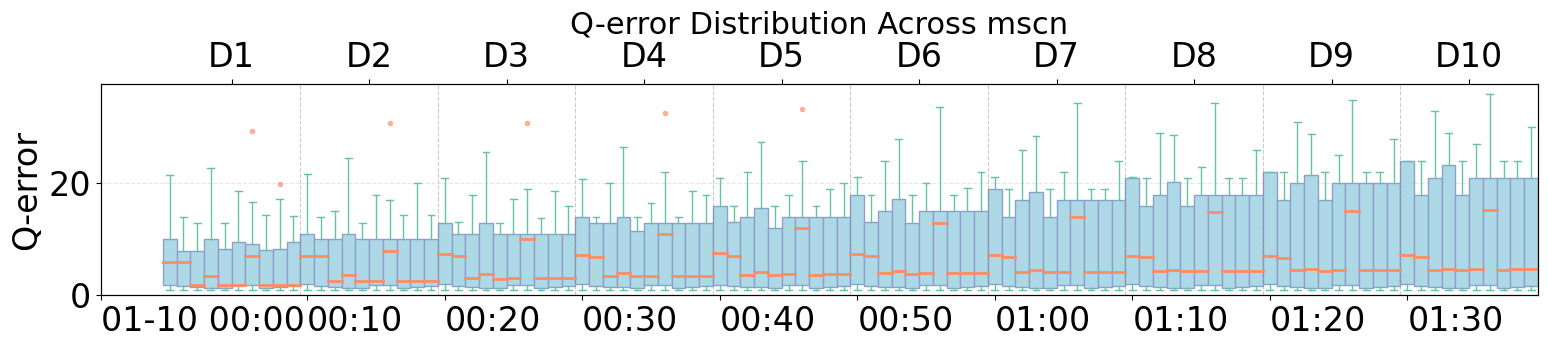

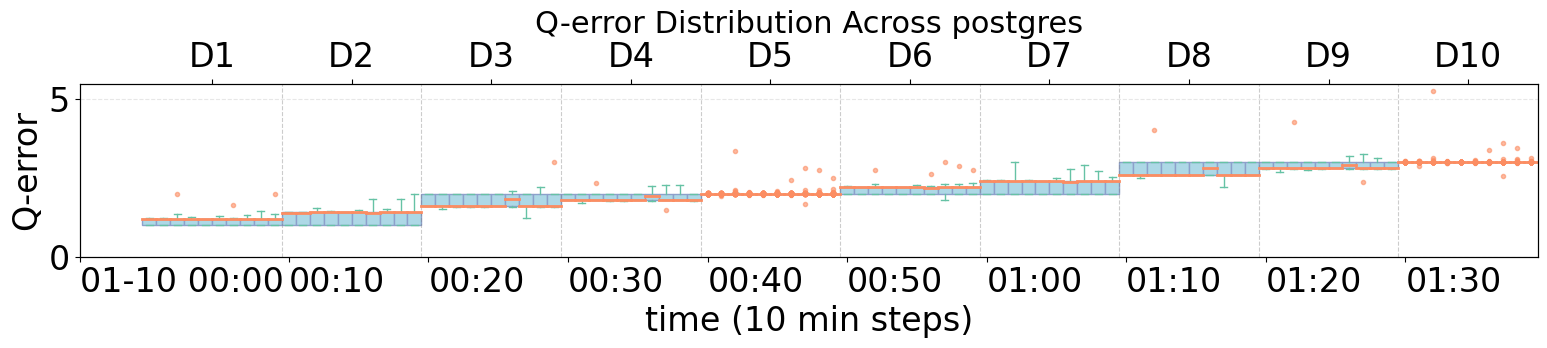

In [21]:
def plot_workload_boxplot(workload):
    steps, data = _build_workload_data(df, workload)
    if not steps:
        return

    labels = _step_labels(steps)

    for est in ESTIMATORS:
        values = []
        for step in steps:
            segments = _segment_values(data[step].get(est, [FALLBACK_VALUE]), SEGMENTS_PER_STEP)
            values.extend(segments)

        positions = list(range(1, len(values) + 1))
        fig, ax = plt.subplots(figsize=(16, 4))
        ax.boxplot(
            values,
            positions=positions,
            widths=BOX_WIDTH,
            patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="#8da0cb"),
            medianprops=dict(color="#fc8d62", linewidth=2),
            whiskerprops=dict(color="#66c2a5"),
            capprops=dict(color="#66c2a5"),
            flierprops=dict(
                marker="o",
                markersize=3,
                alpha=0.6,
                markerfacecolor="#fc8d62",
                markeredgecolor="#fc8d62",
            ),
        )
        ax.set_xlim(0.5, len(values) + 0.5)
        if SEGMENTS_PER_STEP <= 1:
            ax.set_xticks(range(1, len(values) + 1))
            ax.set_xticklabels(labels)
            ax.set_xlabel("time (10 min steps)")
        else:
            total = len(steps) * SEGMENTS_PER_STEP
            centers_1 = [i * SEGMENTS_PER_STEP + 1 for i in range(len(steps))]
            centers_1[0] = -4
            centers_2 = [i * SEGMENTS_PER_STEP + (SEGMENTS_PER_STEP + 1) / 2 for i in range(len(steps))]
            ax.set_xticks(centers_1)
            ax.set_xticklabels(labels, rotation=0, ha="left")
            if ESTIMATORS[-1] == est:
                ax.set_xlabel("time (10 min steps)", fontsize=TICK_SIZE)
            for i in range(1, len(steps)):
                ax.axvline(i * SEGMENTS_PER_STEP + 0.5, linestyle="--", color="gray", alpha=0.4, linewidth=0.8)
            ax_top = ax.twiny()
            ax_top.set_xlim(ax.get_xlim())
            workload_labels = [f"D{i+1}" for i in range(len(steps))]
            ax_top.set_xticks(centers_2)
            ax_top.set_xticklabels(workload_labels, fontsize=TICK_SIZE)
            # ax_top.set_xlabel("workload")
        ax.set_ylabel("Q-error")
        ax.set_ylim(bottom=0)
        ax.set_title(f"Q-error Distribution Across {est}", fontsize=22)
        ax.grid(True, axis="y", linestyle="--", alpha=0.3)
        if USE_LOG_SCALE:
            ax.set_yscale("log")
        fig.tight_layout()
        _save_fig(fig, f"{workload}_{est}_boxplot")
        plt.show()

if PLOT_STYLE == "boxplot":
    for workload in workloads:
        plot_workload_boxplot(workload)
